### Load data from parquet saved in data/raw/

In [44]:
# Import Libraries
# import sys
# import os
# from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
# import pvlib
from pvlib.location import Location

In [45]:
# Load both solar and weather data from perquet
df_solar = pd.read_parquet("../data/raw/solar_2022_2024.parquet")
df_weather = pd.read_parquet("../data/raw/weather_2022_2024.parquet")
print(f"The shape of solar DataFrame is: {df_solar.shape}")
print(f"The shape of weather DataFrame is: {df_weather.shape}")

The shape of solar DataFrame is: (26281, 3)
The shape of weather DataFrame is: (26304, 5)


### Monthly solar averages

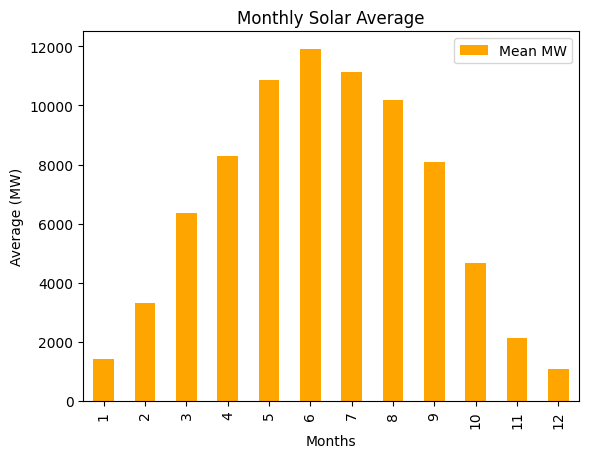

In [46]:
fig, ax = plt.subplots()


df_solar.groupby(df_solar["time"].dt.month)["solar_mw"].mean().plot(
    kind='bar', 
    color='orange', 
    ax=ax, 
    label='Mean MW'
)

ax.set_title('Monthly Solar Average')
ax.set_xlabel('Months')
ax.set_ylabel('Average (MW)')
ax.legend()

plt.show()

### Hour-of-day averages

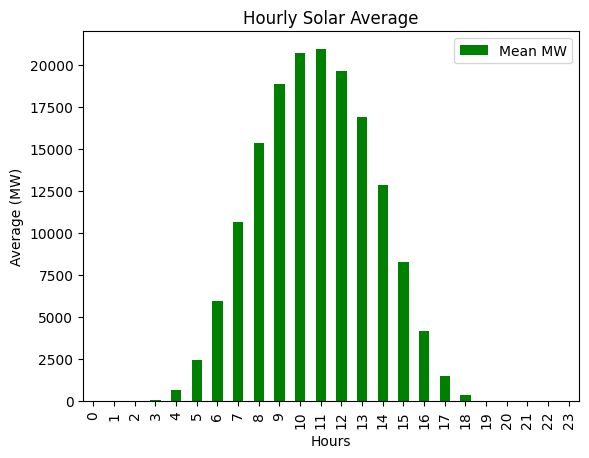

In [47]:
fig, ax = plt.subplots()


df_solar.groupby(df_solar["time"].dt.hour)["solar_mw"].mean().plot(
    kind='bar', 
    color='green', 
    ax=ax, 
    label='Mean MW'
)

ax.set_title('Hourly Solar Average')
ax.set_xlabel('Hours')
ax.set_ylabel('Average (MW)')
ax.legend()

plt.show()

### Solar vs cloud cover scatter

                       time  solar_mw  hour  shortwave_radiation  cloud_cover  \
0 2022-01-01 00:00:00+00:00       2.0     0                  0.0          100   
1 2022-01-01 01:00:00+00:00       2.0     1                  0.0          100   
2 2022-01-01 02:00:00+00:00       2.0     2                  0.0          100   
3 2022-01-01 03:00:00+00:00       2.0     3                  0.0           96   
4 2022-01-01 04:00:00+00:00       2.0     4                  0.0          100   

   temperature_2m  wind_speed_10m  
0            10.5            16.8  
1            10.6            17.2  
2            10.4            17.8  
3            10.5            19.5  
4             9.7            15.9  
(26281, 7)


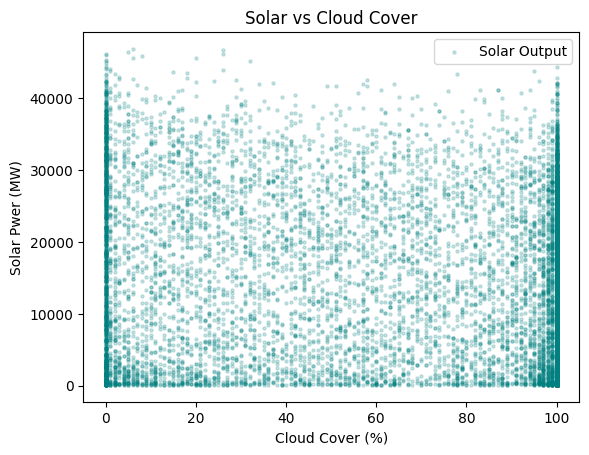

In [ ]:
df_solar_weather = pd.merge(df_solar, df_weather, on="time")
print(df_solar_weather.head())
print(df_solar_weather.shape)
df_daylight = df_solar_weather[df_solar_weather['solar_mw'] > 100]
fig, ax = plt.subplots()
ax.scatter(df_daylight["cloud_cover"], df_daylight["solar_mw"], color='teal', alpha=0.2, s=5)
ax.set_title('Solar vs Cloud Cover')
ax.set_xlabel('Cloud Cover (%)')
ax.set_ylabel('Solar Power (MW)')
ax.legend(['Solar Output'])

plt.show()

### Solar vs shortwave_radiation scatter

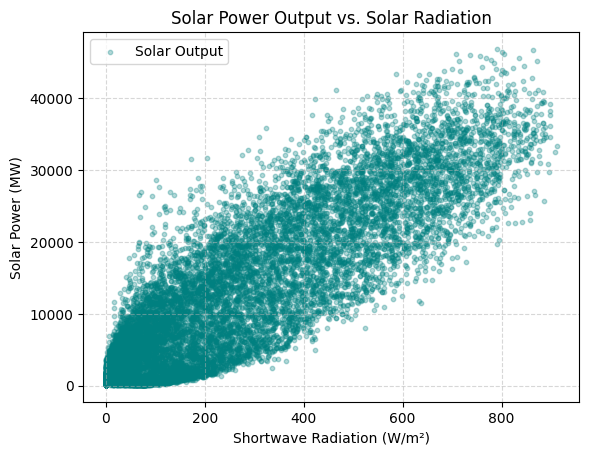

In [49]:
df_solar_weather = pd.merge(df_solar, df_weather, on="time")
df_solar_weather.head()
df_daylight = df_solar_weather[df_solar_weather['solar_mw'] > 100]
fig, ax = plt.subplots()


ax.scatter(df_daylight["shortwave_radiation"], 
           df_daylight["solar_mw"], 
           color='teal', 
           alpha=0.3, 
           s=10)


ax.set_title('Solar Power Output vs. Solar Radiation')
ax.set_xlabel('Shortwave Radiation (W/m²)')
ax.set_ylabel('Solar Power (MW)')

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(['Solar Output'])

plt.show()

### Accessing pvlib data

In [50]:
# Create the Location object
site = Location(
    latitude=51.2, 
    longitude=10.4, 
    tz="UTC", 
    altitude=200, 
    name="Germany Centre"
)

# Get the timestamps from the merged DataFrame
times = pd.DatetimeIndex(df_solar_weather["time"])

# Get the clear sky data
clearsky = site.get_clearsky(times)

# add the 'ghi' (Global Horizontal Irradiance) to the  main DataFrame
# .values ensures it aligns correctly if the indexes are slightly different
df_solar_weather["clear_sky_ghi"] = clearsky["ghi"].values

print(df_solar_weather[["time", "shortwave_radiation", "clear_sky_ghi"]].head(10))

                       time  shortwave_radiation  clear_sky_ghi
0 2022-01-01 00:00:00+00:00                  0.0       0.000000
1 2022-01-01 01:00:00+00:00                  0.0       0.000000
2 2022-01-01 02:00:00+00:00                  0.0       0.000000
3 2022-01-01 03:00:00+00:00                  0.0       0.000000
4 2022-01-01 04:00:00+00:00                  0.0       0.000000
5 2022-01-01 05:00:00+00:00                  0.0       0.000000
6 2022-01-01 06:00:00+00:00                  0.0       0.000000
7 2022-01-01 07:00:00+00:00                  0.0       0.000000
8 2022-01-01 08:00:00+00:00                  4.0      20.510860
9 2022-01-01 09:00:00+00:00                 58.0     110.629687


### find the scaling factor as solar_mw (what actually happened) and clear_sky_ghi (what physics says should happen under clear sky) have different units. GHI is in W/m², solar is in MW. 

In [51]:
# It's a rough proxy for installed capacity × panel efficiency × area.

# 'time' is the index so everything aligns perfectly
df_solar_weather = df_solar_weather.set_index("time")

# get the Clear Sky data (GHI) using the site object 
times = df_solar_weather.index
clearsky = site.get_clearsky(times)

# add GHI to the main dataframe
df_solar_weather["clear_sky_ghi"] = clearsky["ghi"]

# Filter for daylight hours (where the sun is actually up)
df_daylight = df_solar_weather[df_solar_weather["solar_mw"] > 100].copy()

# Calculate Scaling Factor 
mask = df_daylight["clear_sky_ghi"] > 10
mean_solar = df_daylight.loc[mask, "solar_mw"].mean()
mean_ghi = df_daylight.loc[mask, "clear_sky_ghi"].mean()

scaling_factor = mean_solar / mean_ghi
print(f"Scaling Factor: {scaling_factor:.4f}")


Scaling Factor: 37.4992


### compute the physics prediction

In [52]:
df_solar_weather["physics_pred"] = df_solar_weather["clear_sky_ghi"] * scaling_factor
print(df_solar_weather["physics_pred"].head())

time
2022-01-01 00:00:00+00:00    0.0
2022-01-01 01:00:00+00:00    0.0
2022-01-01 02:00:00+00:00    0.0
2022-01-01 03:00:00+00:00    0.0
2022-01-01 04:00:00+00:00    0.0
Name: physics_pred, dtype: float64


### compute the residual

In [53]:
df_solar_weather["residual"] = df_solar_weather["solar_mw"] - df_solar_weather["physics_pred"]
print(df_solar_weather["residual"].head())

time
2022-01-01 00:00:00+00:00    2.0
2022-01-01 01:00:00+00:00    2.0
2022-01-01 02:00:00+00:00    2.0
2022-01-01 03:00:00+00:00    2.0
2022-01-01 04:00:00+00:00    2.0
Name: residual, dtype: float64


### Plot solar_mw, physics_pred, and residual on the same chart (one week of July 2023). 
**Expectations:**
- `physics_pred` = smooth bell curves, cloud-free perfect world
- `solar_mw` = messier, dips below physics on cloudy days
- `residual` = the gap, negative when clouds reduce output, near-zero on clear days

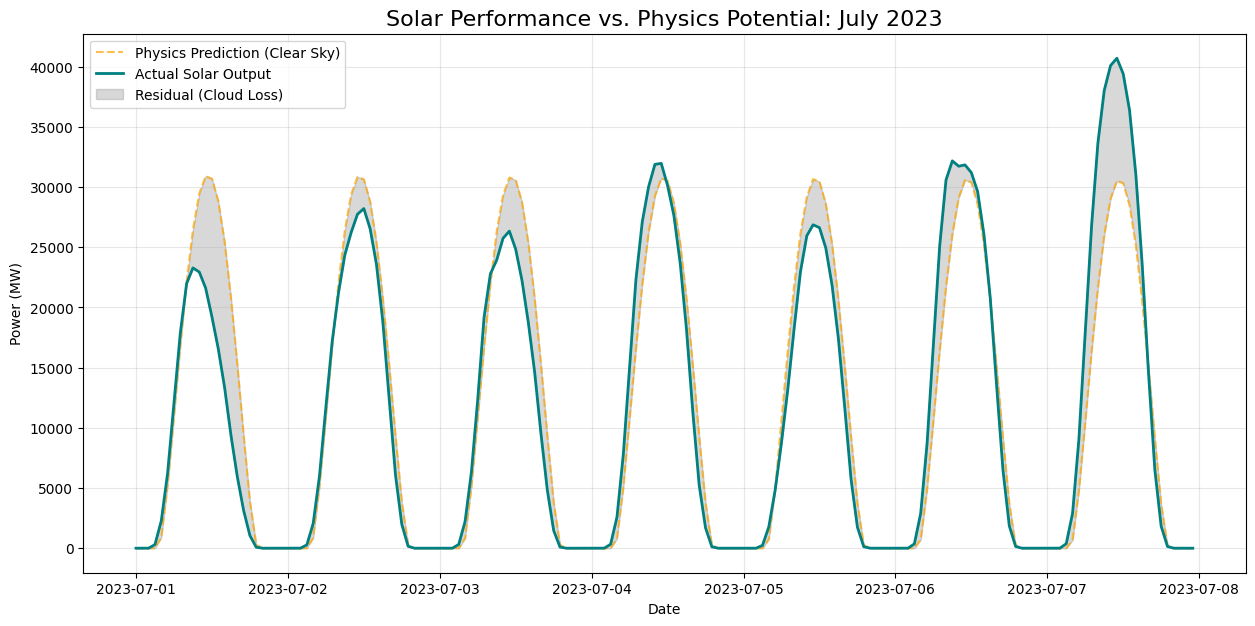

In [54]:
# One weel of July 2023
week_july = df_solar_weather.loc['2023-07-01':'2023-07-07']
# Plot the smooth "Ideal" data
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(week_july.index, week_july["physics_pred"], 
        label="Physics Prediction (Clear Sky)", color="orange", linestyle="--", alpha=0.7)

# Plot the messy "Real World" data
ax.plot(week_july.index, week_july["solar_mw"], 
        label="Actual Solar Output", color="teal", linewidth=2)

# Plot the Residual (The Gap)
ax.fill_between(week_july.index, week_july["physics_pred"], week_july["solar_mw"], 
                color='gray', alpha=0.3, label="Residual (Cloud Loss)")

# Formatting for clarity
ax.set_title("Solar Performance vs. Physics Potential: July 2023", fontsize=16)
ax.set_ylabel("Power (MW)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

> Scaling factor of 37.5 MW per W/m². Sanity check: Germany peak output was ~47,000 MW at ~800 W/m² peak GHI → 47,000/800 ≈ 59 at peak. Our mean-based 37.5 is lower because averages include winter/morning hours with low sun angles — physically consistent.